# Ames 주택 가격 예측 모델 (House Price Prediction)
---

# 1. 환경 설정 및 라이브러리 임포트

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

# 통계
from scipy import stats
from scipy.stats import skew, kurtosis
from sklearn.model_selection import cross_val_score


# 전처리
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.special import boxcox1p
from scipy.stats import boxcox_normmax
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 회귀
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# 트리
import xgboost as xgb
import lightgbm as lgb

# 하이퍼파라미터 (optuna 사용)
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)


# 시각화 
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# 기타
pd.set_option('display.max_columns', None)  # 모든 컬럼 표시
pd.set_option('display.max_rows', 100)  # 최대 100행까지 표시
pd.set_option('display.float_format', '{:.4f}'.format)  # 소수점 4자리까지 표시

import warnings
warnings.filterwarnings('ignore')

# 2. 데이터 로드, 기본 정보 확인

In [2]:
train_df = pd.read_csv('./train.csv')
test_df = pd.read_csv('./test.csv')

In [3]:
print(f" train_df.shape: {train_df.shape}")
print(f" test_df.shape: {test_df.shape}")
train_df.head()

 train_df.shape: (1168, 81)
 test_df.shape: (292, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,968,20,RL,NaN,7390,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,7,1955,1955,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,151.0000,TA,TA,CBlock,TA,TA,No,ALQ,902,Unf,0,196,1098,GasA,TA,Y,SBrkr,1098,0,0,1098,1,0,1,0,3,1,TA,6,Typ,0,NaN,Attchd,1955.0000,Unf,1,260,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,7,2008,WD,Normal,135000
1,739,90,RL,60.0000,10800,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,Duplex,1Story,5,5,1987,1988,Gable,CompShg,Plywood,Plywood,NaN,0.0000,TA,TA,CBlock,Gd,Gd,Gd,GLQ,1200,Unf,0,0,1200,GasA,TA,Y,SBrkr,1200,0,0,1200,3,0,3,0,3,1,TA,5,Typ,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,Y,120,0,0,0,0,0,NaN,NaN,NaN,0,3,2009,WD,Alloca,179000
2,696,20,RL,54.0000,13811,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Timber,Norm,Norm,1Fam,1Story,6,6,1987,1987,Gable,CompShg,HdBoard,HdBoard,BrkFace,72.0000,TA,TA,CBlock,Gd,Gd,No,GLQ,980,LwQ,40,92,1112,GasA,Gd,Y,SBrkr,1137,0,0,1137,1,0,2,0,2,1,Gd,5,Typ,1,TA,Attchd,1987.0000,Unf,2,551,TA,TA,Y,125,0,0,0,0,0,NaN,NaN,NaN,0,7,2006,WD,Normal,176000
3,239,20,RL,93.0000,12030,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NridgHt,Norm,Norm,1Fam,1Story,8,5,2007,2007,Hip,CompShg,VinylSd,VinylSd,BrkFace,254.0000,Ex,TA,PConc,Ex,TA,No,Unf,0,Unf,0,1694,1694,GasA,Ex,Y,SBrkr,1694,0,0,1694,0,0,2,0,3,1,Gd,7,Typ,0,NaN,Attchd,2007.0000,Fin,3,818,TA,TA,Y,168,228,0,0,0,0,NaN,NaN,NaN,0,12,2007,New,Partial,318000
4,891,50,RL,60.0000,8064,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Artery,Norm,1Fam,1.5Fin,5,7,1949,2006,Gable,CompShg,MetalSd,MetalSd,NaN,0.0000,TA,Gd,CBlock,TA,TA,Mn,Unf,0,Unf,0,672,672,GasA,Ex,Y,SBrkr,672,252,0,924,0,0,1,0,3,1,TA,6,Typ,1,Po,Detchd,2003.0000,Unf,2,576,TA,TA,Y,0,0,0,0,0,0,NaN,MnPrv,Shed,2000,7,2007,WD,Normal,122900


In [4]:
print("train_df.info()")
train_df.info()

print("\n" + "="*80)

print("train_df.describe()")
train_df.describe()

train_df.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1168 entries, 0 to 1167
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1168 non-null   int64  
 1   MSSubClass     1168 non-null   int64  
 2   MSZoning       1168 non-null   object 
 3   LotFrontage    950 non-null    float64
 4   LotArea        1168 non-null   int64  
 5   Street         1168 non-null   object 
 6   Alley          70 non-null     object 
 7   LotShape       1168 non-null   object 
 8   LandContour    1168 non-null   object 
 9   Utilities      1168 non-null   object 
 10  LotConfig      1168 non-null   object 
 11  LandSlope      1168 non-null   object 
 12  Neighborhood   1168 non-null   object 
 13  Condition1     1168 non-null   object 
 14  Condition2     1168 non-null   object 
 15  BldgType       1168 non-null   object 
 16  HouseStyle     1168 non-null   object 
 17  OverallQual    1168 non-null   int64

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1168.0000,1168.0000,950.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1160.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1099.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000
mean,728.5283,56.9777,70.0589,10336.3579,6.1053,5.5959,1971.2012,1985.0214,102.9388,442.9289,42.5377,574.7089,1060.1755,1161.7483,344.8536,5.0942,1511.6961,0.4255,0.0582,1.5625,0.3887,2.8656,1.0471,6.5111,0.6259,1978.4049,1.7611,469.8887,90.9717,47.5548,22.7158,3.2192,16.3322,2.9555,51.2791,6.3065,2007.8305,180194.4015
std,415.3935,42.2907,24.7624,8784.8546,1.3730,1.1274,30.3624,20.6933,176.1426,462.3647,151.6707,440.9595,439.2239,392.6622,438.5026,44.8760,535.7078,0.5183,0.2415,0.5519,0.5066,0.8248,0.2237,1.6398,0.6542,24.9884,0.7465,213.6048,123.8117,68.2501,63.0430,29.2412,58.8280,41.6485,552.3576,2.7160,1.3236,78869.2015
min,1.0000,20.0000,21.0000,1300.0000,1.0000,1.0000,1872.0000,1950.0000,0.0000,0.0000,0.0000,0.0000,0.0000,334.0000,0.0000,0.0000,334.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,0.0000,1908.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,2006.0000,34900.0000
25%,373.7500,20.0000,59.0000,7560.0000,5.0000,5.0000,1954.0000,1966.7500,0.0000,0.0000,0.0000,233.0000,793.0000,880.0000,0.0000,0.0000,1126.0000,0.0000,0.0000,1.0000,0.0000,2.0000,1.0000,5.0000,0.0000,1962.0000,1.0000,336.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,5.0000,2007.0000,129500.0000
50%,720.5000,50.0000,69.0000,9446.0000,6.0000,5.0000,1972.5000,1994.0000,0.0000,374.5000,0.0000,485.5000,990.0000,1077.5000,0.0000,0.0000,1456.0000,0.0000,0.0000,2.0000,0.0000,3.0000,1.0000,6.0000,1.0000,1980.0000,2.0000,477.5000,0.0000,25.5000,0.0000,0.0000,0.0000,0.0000,0.0000,6.0000,2008.0000,163995.0000
75%,1086.2500,70.0000,80.0000,11601.5000,7.0000,6.0000,2001.0000,2004.0000,168.0000,714.5000,0.0000,813.2500,1306.0000,1392.5000,728.0000,0.0000,1774.2500,1.0000,0.0000,2.0000,1.0000,3.0000,1.0000,7.0000,1.0000,2002.0000,2.0000,576.0000,165.0000,68.0000,0.0000,0.0000,0.0000,0.0000,0.0000,8.0000,2009.0000,213062.5000
max,1460.0000,190.0000,313.0000,164660.0000,10.0000,9.0000,2010.0000,2010.0000,1170.0000,5644.0000,1474.0000,2153.0000,6110.0000,4692.0000,2065.0000,572.0000,5642.0000,3.0000,2.0000,3.0000,2.0000,8.0000,3.0000,14.0000,3.0000,2010.0000,4.0000,1418.0000,736.0000,547.0000,552.0000,508.0000,480.0000,738.0000,15500.0000,12.0000,2010.0000,755000.0000


# 3. EDA



## 3.1 타겟 변수(SalePrice) 분석

In [5]:
# SalePrice 왜도,첨도
saleprice_skewness = skew(train_df['SalePrice'])
saleprice_kurtosis = kurtosis(train_df['SalePrice'])

print(f"왜도: {saleprice_skewness:.4f}")
print(f"첨도: {saleprice_kurtosis:.4f}")

왜도: 1.9553
첨도: 7.3691


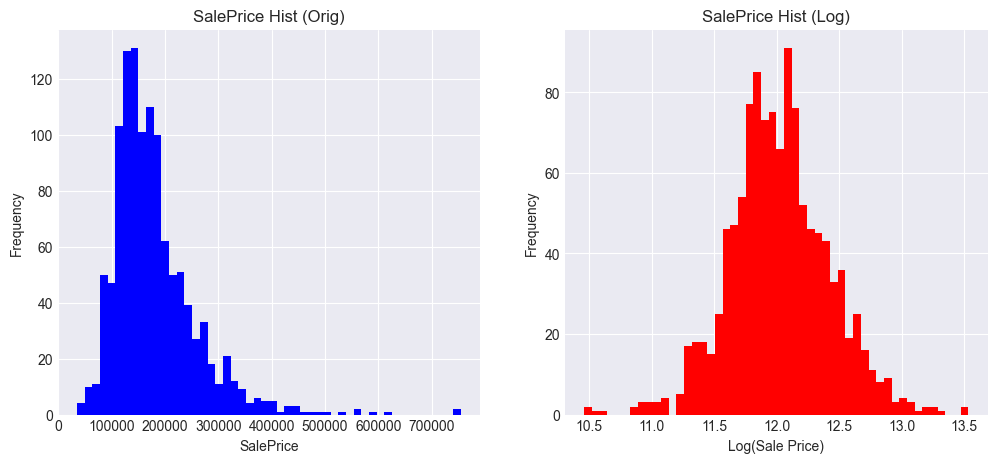

In [6]:
# 주택 가격 분포 확인, 정규성검토 -> 로그 변환 후 분포가 정규분포에 더 가까움 

# SalePrice 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. 히스토그램
axes[0].hist(train_df['SalePrice'], bins=50, color='blue')
axes[0].set_xlabel('SalePrice')
axes[0].set_ylabel('Frequency')
axes[0].set_title('SalePrice Hist (Orig)')


# 3. 로그 변환 후 히스토그램
log_saleprice = np.log1p(train_df['SalePrice'])  # log1p = log(1 + x) -> 0값 처리
axes[1].hist(log_saleprice, bins=50, color='red')
axes[1].set_xlabel('Log(Sale Price)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('SalePrice Hist (Log)')


plt.show()

## 3.2 결측치 분석

In [7]:
# 결측치 확인
missing_train = train_df.isnull().sum()
missing_train.sort_values(ascending=False)

PoolQC           1162
MiscFeature      1120
Alley            1098
Fence             941
MasVnrType        694
FireplaceQu       545
LotFrontage       218
GarageYrBlt        69
GarageCond         69
GarageType         69
GarageFinish       69
GarageQual         69
BsmtFinType2       24
BsmtExposure       24
BsmtQual           23
BsmtCond           23
BsmtFinType1       23
MasVnrArea          8
Electrical          1
Id                  0
Functional          0
Fireplaces          0
KitchenQual         0
KitchenAbvGr        0
BedroomAbvGr        0
HalfBath            0
FullBath            0
BsmtHalfBath        0
TotRmsAbvGrd        0
GarageCars          0
GrLivArea           0
GarageArea          0
PavedDrive          0
WoodDeckSF          0
OpenPorchSF         0
EnclosedPorch       0
3SsnPorch           0
ScreenPorch         0
PoolArea            0
MiscVal             0
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
BsmtFullBath        0
HeatingQC 

In [8]:
# 결측치 비율
missing_train_per = train_df.isnull().mean()
missing_train_per.sort_values(ascending=False)


PoolQC          0.9949
MiscFeature     0.9589
Alley           0.9401
Fence           0.8057
MasVnrType      0.5942
FireplaceQu     0.4666
LotFrontage     0.1866
GarageYrBlt     0.0591
GarageCond      0.0591
GarageType      0.0591
GarageFinish    0.0591
GarageQual      0.0591
BsmtFinType2    0.0205
BsmtExposure    0.0205
BsmtQual        0.0197
BsmtCond        0.0197
BsmtFinType1    0.0197
MasVnrArea      0.0068
Electrical      0.0009
Id              0.0000
Functional      0.0000
Fireplaces      0.0000
KitchenQual     0.0000
KitchenAbvGr    0.0000
BedroomAbvGr    0.0000
HalfBath        0.0000
FullBath        0.0000
BsmtHalfBath    0.0000
TotRmsAbvGrd    0.0000
GarageCars      0.0000
GrLivArea       0.0000
GarageArea      0.0000
PavedDrive      0.0000
WoodDeckSF      0.0000
OpenPorchSF     0.0000
EnclosedPorch   0.0000
3SsnPorch       0.0000
ScreenPorch     0.0000
PoolArea        0.0000
MiscVal         0.0000
MoSold          0.0000
YrSold          0.0000
SaleType        0.0000
SaleConditi

## 3.3 상관관계 분석

### 수치형, 변수간 상관관계 + VIF

In [9]:
# 수치형 변수 선택
numeric_cols = train_df.select_dtypes(include=[np.number]).columns
correlation_matrix = train_df[numeric_cols].corr()


# 상관계수 절댓값 기준으로 높은 순 정렬
def get_high_corr_pairs(corr_matrix, threshold=0.7):
    """threshold 이상의 상관관계를 가진 변수 쌍 추출"""
    high_corr = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) >= threshold:
                high_corr.append({
                    'var1': corr_matrix.columns[i],
                    'var2': corr_matrix.columns[j],
                    'correlation': corr_matrix.iloc[i, j]
                })
    return pd.DataFrame(high_corr).sort_values('correlation',
                                               key=abs,
                                               ascending=False)


high_corr_pairs = get_high_corr_pairs(correlation_matrix, threshold=0.7)
print(high_corr_pairs)




          var1          var2  correlation
5   GarageCars    GarageArea       0.8823
2  TotalBsmtSF      1stFlrSF       0.8374
3    GrLivArea  TotRmsAbvGrd       0.8290
1    YearBuilt   GarageYrBlt       0.8281
0  OverallQual     SalePrice       0.7851
4    GrLivArea     SalePrice       0.7102


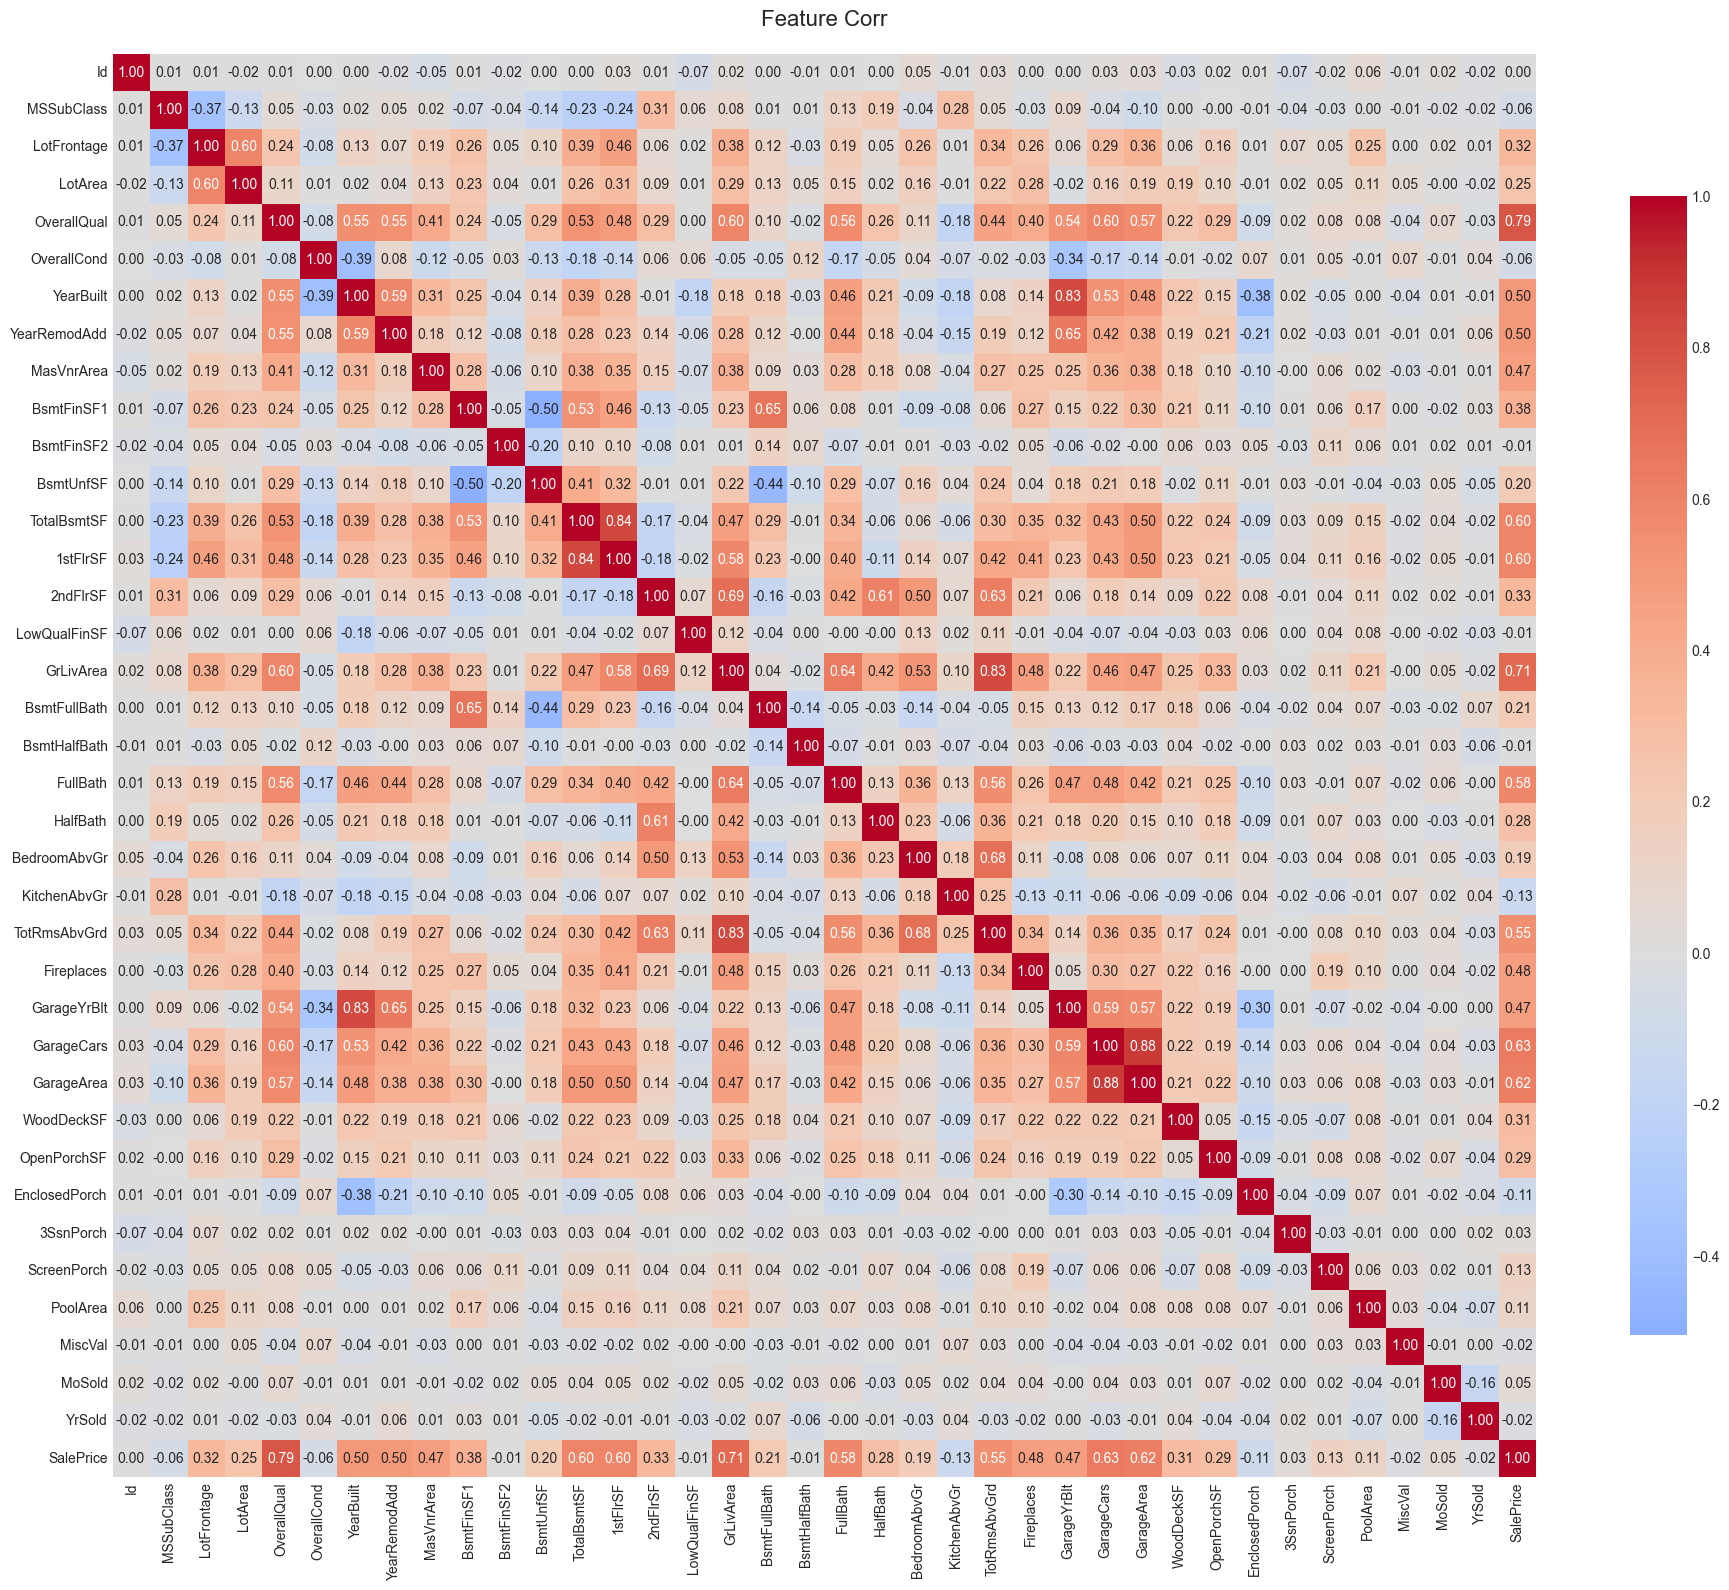

In [10]:
# 히트맵 시각화
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',  # 색상: 빨강(양), 파랑(음)
            center=0,    # 0을 중심으로 색상 분포
            square=True,
            cbar_kws={"shrink": 0.8})
plt.title('Feature Corr', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [11]:
# VIF 계산
# 수치형 변수만 선택 (target 변수 제외)
# Id는 식별자이므로 제외
feature_cols = numeric_cols.drop(['Id', 'SalePrice'])  # SalePrice가 target이라 가정
X = train_df[feature_cols]


# 결측치 처리 (VIF 계산 전 필수)
X = X.fillna(X.median())


# VIF 계산
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                   for i in range(len(X.columns))]

# VIF 높은 순 정렬
vif_data = vif_data.sort_values('VIF', ascending=False)
vif_data

# 문제 변수 필터링
print(vif_data[vif_data['VIF'] > 10])
print(vif_data[vif_data['VIF'] > 5])

         Feature        VIF
9     BsmtFinSF2        inf
8     BsmtFinSF1        inf
15     GrLivArea        inf
14  LowQualFinSF        inf
13      2ndFlrSF        inf
12      1stFlrSF        inf
11   TotalBsmtSF        inf
10     BsmtUnfSF        inf
35        YrSold 23387.2520
6   YearRemodAdd 23030.1563
24   GarageYrBlt 22148.8279
5      YearBuilt 20828.7512
22  TotRmsAbvGrd    84.0040
3    OverallQual    65.8456
4    OverallCond    41.5631
21  KitchenAbvGr    36.3936
25    GarageCars    36.3384
26    GarageArea    32.8338
20  BedroomAbvGr    30.9513
18      FullBath    26.7229
1    LotFrontage    16.8778
         Feature        VIF
9     BsmtFinSF2        inf
8     BsmtFinSF1        inf
15     GrLivArea        inf
14  LowQualFinSF        inf
13      2ndFlrSF        inf
12      1stFlrSF        inf
11   TotalBsmtSF        inf
10     BsmtUnfSF        inf
35        YrSold 23387.2520
6   YearRemodAdd 23030.1563
24   GarageYrBlt 22148.8279
5      YearBuilt 20828.7512
22  TotRmsAbvGrd    

### 수치형

In [12]:
# 수치형 변수만 선택
numeric_features = train_df.select_dtypes(include=[np.number]).columns.tolist()

# SalePrice와 상관계수 계산
correlations = train_df[numeric_features].corr()['SalePrice'].sort_values(ascending=False)
correlations

SalePrice        1.0000
OverallQual      0.7851
GrLivArea        0.7102
GarageCars       0.6326
GarageArea       0.6183
1stFlrSF         0.5977
TotalBsmtSF      0.5959
FullBath         0.5779
TotRmsAbvGrd     0.5488
YearRemodAdd     0.5048
YearBuilt        0.5018
Fireplaces       0.4760
GarageYrBlt      0.4725
MasVnrArea       0.4693
BsmtFinSF1       0.3796
2ndFlrSF         0.3332
LotFrontage      0.3214
WoodDeckSF       0.3081
OpenPorchSF      0.2948
HalfBath         0.2793
LotArea          0.2516
BsmtFullBath     0.2097
BsmtUnfSF        0.1973
BedroomAbvGr     0.1862
ScreenPorch      0.1331
PoolArea         0.1144
MoSold           0.0493
3SsnPorch        0.0287
Id               0.0032
BsmtFinSF2      -0.0051
BsmtHalfBath    -0.0055
LowQualFinSF    -0.0079
YrSold          -0.0182
MiscVal         -0.0218
OverallCond     -0.0599
MSSubClass      -0.0607
EnclosedPorch   -0.1103
KitchenAbvGr    -0.1329
Name: SalePrice, dtype: float64

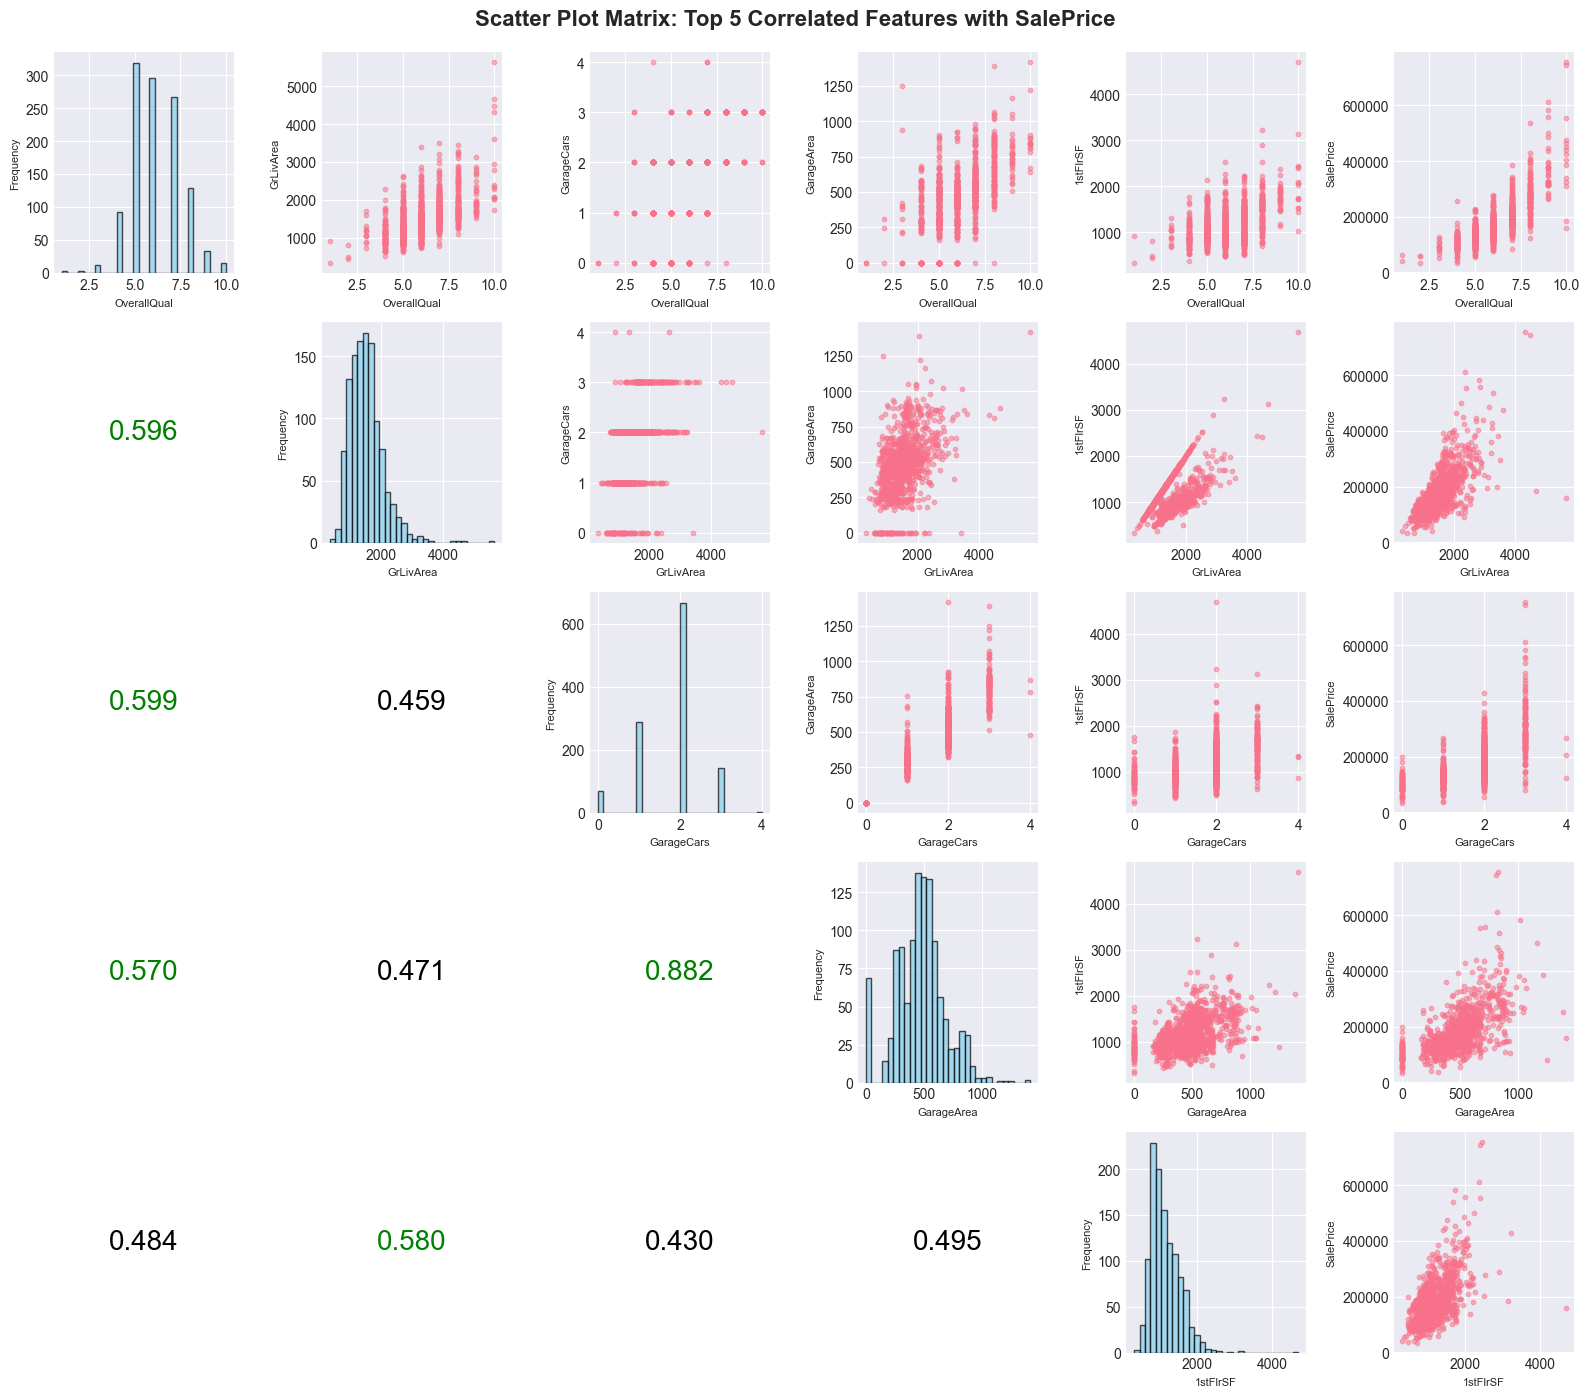

In [13]:
# 상위 상관관계 변수들 scatterplot
top_features = correlations.head(6)[1:].index.tolist()  # 상위 5개 변수
top_features.append('SalePrice')

fig = plt.figure(figsize=(16, 14))
for i, feature in enumerate(top_features[:-1]):
    for j, feature2 in enumerate(top_features):
        ax = plt.subplot(5, 6, i * 6 + j + 1)
        if i < j:
            # 상단 삼각형: 산점도
            ax.scatter(train_df[feature], train_df[feature2], alpha=0.5, s=10)
            ax.set_xlabel(feature, fontsize=8)
            ax.set_ylabel(feature2, fontsize=8)
        elif i == j:
            # 대각선: 히스토그램
            ax.hist(train_df[feature], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
            ax.set_ylabel('Frequency', fontsize=8)
            ax.set_xlabel(feature, fontsize=8)
        else:
            # 하단 삼각형: 상관계수
            corr_val = train_df[[feature, feature2]].corr().iloc[0, 1]
            ax.text(0.5, 0.5, f'{corr_val:.3f}', 
                   ha='center', va='center', fontsize=20, 
                   color='green' if abs(corr_val) > 0.5 else 'black')
            ax.set_xlim([0, 1])
            ax.set_ylim([0, 1])
            ax.axis('off')

plt.suptitle('Scatter Plot Matrix: Top 5 Correlated Features with SalePrice', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [14]:
# 수치형 변수 선택
numeric_cols = train_df.select_dtypes(include=[np.number]).columns
correlation_matrix = train_df[numeric_cols].corr()

# 상관계수 절댓값 기준으로 높은 순 정렬
def get_high_corr_pairs(corr_matrix, threshold=0.7):
    """threshold 이상의 상관관계를 가진 변수 쌍 추출"""
    high_corr = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) >= threshold:
                high_corr.append({
                    'var1': corr_matrix.columns[i],
                    'var2': corr_matrix.columns[j],
                    'correlation': corr_matrix.iloc[i, j]
                })
    return pd.DataFrame(high_corr).sort_values('correlation', 
                                               key=abs, 
                                               ascending=False)

high_corr_pairs = get_high_corr_pairs(correlation_matrix, threshold=0.7)
print(high_corr_pairs)

          var1          var2  correlation
5   GarageCars    GarageArea       0.8823
2  TotalBsmtSF      1stFlrSF       0.8374
3    GrLivArea  TotRmsAbvGrd       0.8290
1    YearBuilt   GarageYrBlt       0.8281
0  OverallQual     SalePrice       0.7851
4    GrLivArea     SalePrice       0.7102


### 범주형

In [15]:
# 범주형 변수 선택
categorical_features = train_df.select_dtypes(include=['object']).columns.tolist()
print(len(categorical_features))
categorical_features

43


['MSZoning',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 'KitchenQual',
 'Functional',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'PoolQC',
 'Fence',
 'MiscFeature',
 'SaleType',
 'SaleCondition']

In [16]:
# dtype 기준으로 범주형 선택
cat_unique = train_df.select_dtypes(include=['object', 'category']).nunique().sort_values()
cat_unique

Street            2
Alley             2
CentralAir        2
Utilities         2
MasVnrType        3
LandSlope         3
PoolQC            3
PavedDrive        3
GarageFinish      3
BsmtQual          4
ExterQual         4
KitchenQual       4
GarageCond        4
BsmtCond          4
Fence             4
MiscFeature       4
LandContour       4
LotShape          4
BsmtExposure      4
FireplaceQu       5
Electrical        5
HeatingQC         5
Heating           5
GarageQual        5
MSZoning          5
LotConfig         5
BldgType          5
ExterCond         5
BsmtFinType2      6
RoofStyle         6
BsmtFinType1      6
GarageType        6
Foundation        6
SaleCondition     6
RoofMatl          7
Functional        7
HouseStyle        8
Condition2        8
Condition1        9
SaleType          9
Exterior1st      15
Exterior2nd      16
Neighborhood     25
dtype: int64

In [17]:
# dtype 기준으로 범주형 선택
cat_cols = train_df.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    print(f"\n[{col}]")
    print(train_df[col].value_counts())
    print("-" * 50)


[MSZoning]
MSZoning
RL         920
RM         177
FV          52
RH          13
C (all)      6
Name: count, dtype: int64
--------------------------------------------------

[Street]
Street
Pave    1163
Grvl       5
Name: count, dtype: int64
--------------------------------------------------

[Alley]
Alley
Grvl    37
Pave    33
Name: count, dtype: int64
--------------------------------------------------

[LotShape]
LotShape
Reg    732
IR1    395
IR2     33
IR3      8
Name: count, dtype: int64
--------------------------------------------------

[LandContour]
LandContour
Lvl    1056
Bnk      48
HLS      39
Low      25
Name: count, dtype: int64
--------------------------------------------------

[Utilities]
Utilities
AllPub    1167
NoSeWa       1
Name: count, dtype: int64
--------------------------------------------------

[LotConfig]
LotConfig
Inside     840
Corner     216
CulDSac     75
FR2         33
FR3          4
Name: count, dtype: int64
---------------------------------------------

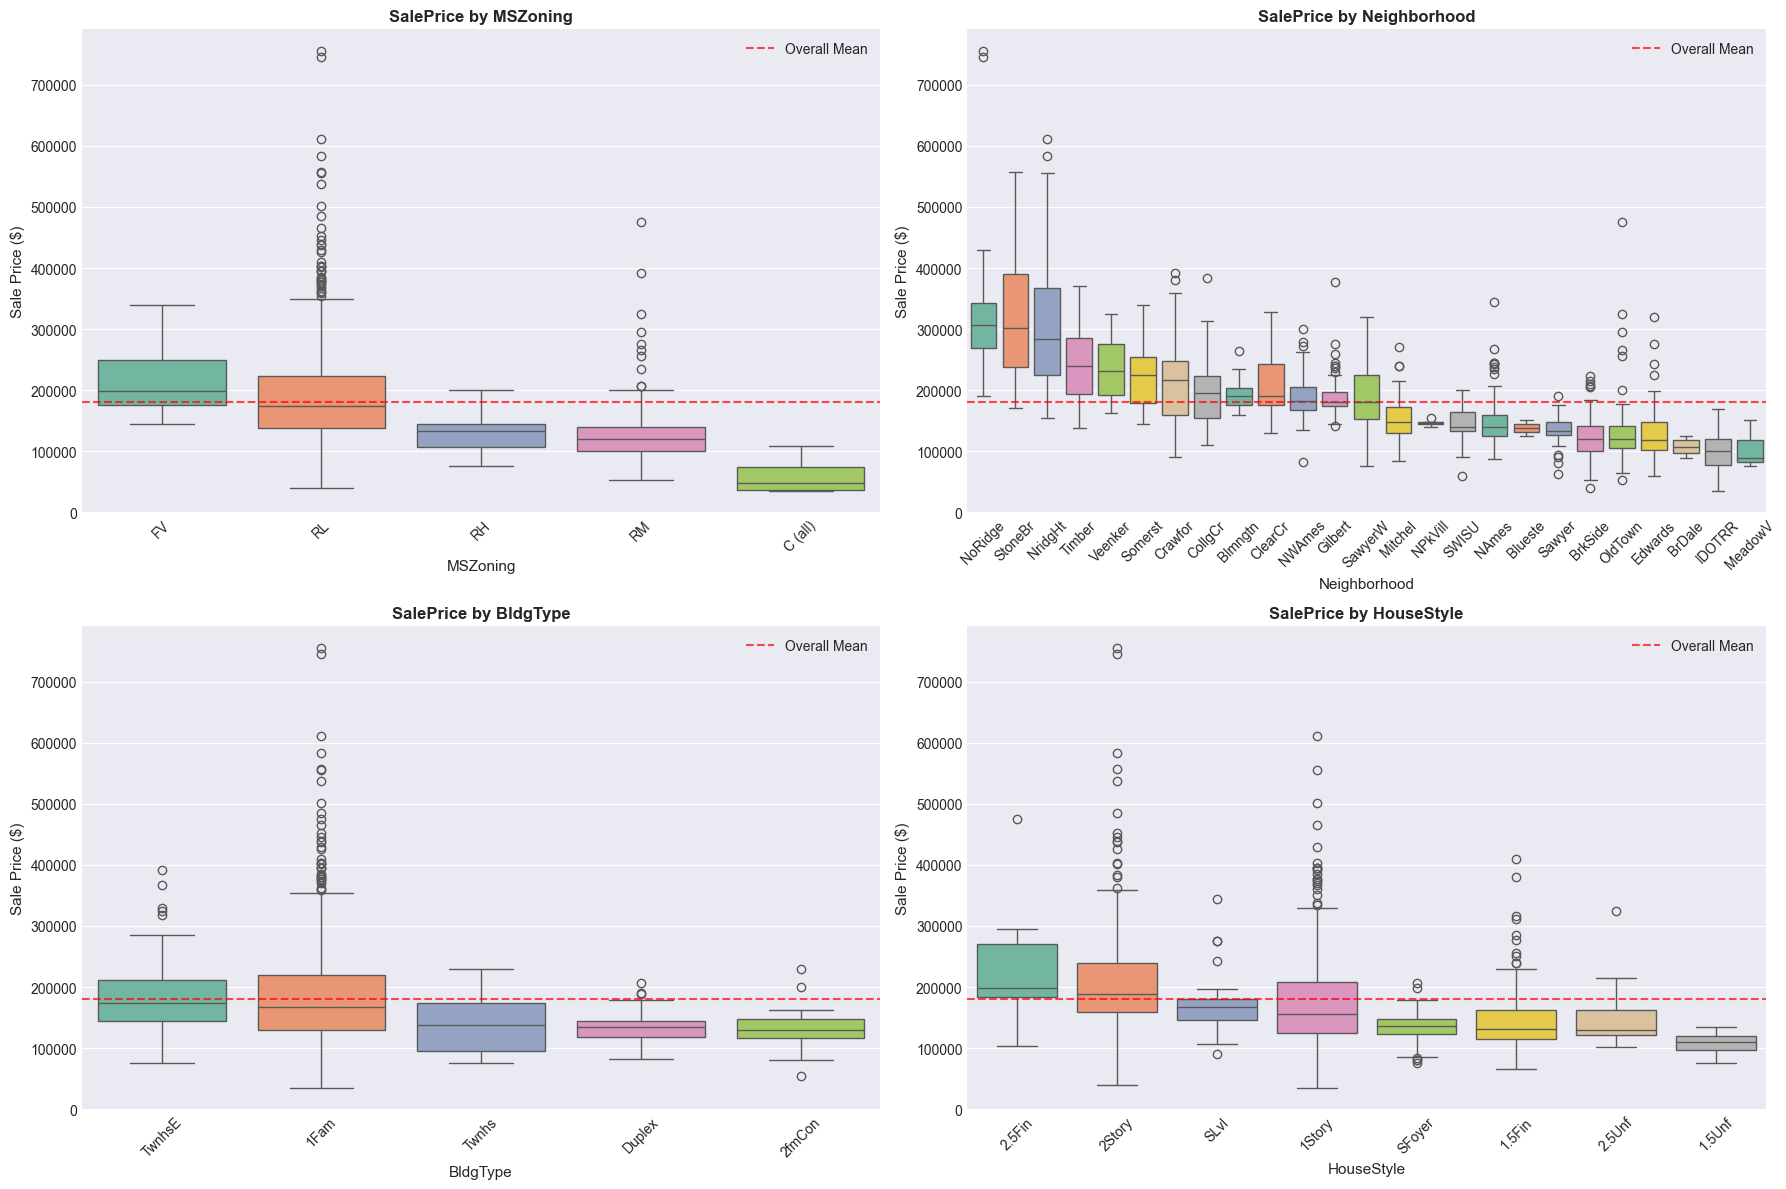

In [18]:
# 주요 범주형 변수-SalePrice 시각화

# 카테고리 수가 적은 변수들 선택
key_categorical = ['MSZoning', 'Neighborhood', 'BldgType', 'HouseStyle']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, cat in enumerate(key_categorical):
    if cat in train_df.columns:
        # 카테고리별 평균 가격 계산 및 정렬
        cat_order = train_df.groupby(cat)['SalePrice'].median().sort_values(ascending=False).index
        
        sns.boxplot(data=train_df, x=cat, y='SalePrice', order=cat_order, ax=axes[i], palette='Set2')
        axes[i].set_title(f'SalePrice by {cat}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel(cat, fontsize=11)
        axes[i].set_ylabel('Sale Price ($)', fontsize=11)
        axes[i].tick_params(axis='x', rotation=45)
        
        # 평균선 추가
        axes[i].axhline(train_df['SalePrice'].mean(), color='red', linestyle='--', 
                       linewidth=1.5, alpha=0.7, label='Overall Mean')
        axes[i].legend()

plt.tight_layout()
plt.show()

# 4. 데이터 전처리

In [19]:
# ===================================================================
# 전처리 + 피처 엔지니어링 통합 파이프라인
# ===================================================================
import numpy as np
import pandas as pd
from scipy.special import boxcox1p
from scipy.stats import boxcox_normmax, skew
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# 원본 데이터 다시 로드 (이전 EDA에서 변형 방지)
train_df = pd.read_csv('./train.csv')
test_df = pd.read_csv('./test.csv')

print("=" * 60)
print("전처리 파이프라인 시작")
print("=" * 60)

# ===== 1단계: 메타데이터 저장 & 합치기 =====
train_len = len(train_df)
test_ids = test_df['Id'].copy()
y_train_full = np.log1p(train_df['SalePrice'])

X_train = train_df.drop(['Id', 'SalePrice'], axis=1)
X_test = test_df.drop(['Id'], axis=1)
all_data = pd.concat([X_train, X_test], axis=0, ignore_index=True)

print(f"\n[1] 데이터 병합: Train={train_len}, Test={len(test_df)}, Total={len(all_data)}")

# ===== 2단계: 결측치 처리 =====
print("\n[2] 결측치 처리")

# '없음'을 의미하는 범주형 → 'None'
none_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]
for col in none_cols:
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna('None')

# '0'을 의미하는 수치형 → 0
zero_cols = [
    'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath', 'GarageYrBlt', 'GarageCars', 'GarageArea'
]
for col in zero_cols:
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna(0)

# LotFrontage: Neighborhood별 중앙값
if 'LotFrontage' in all_data.columns:
    all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(
        lambda x: x.fillna(x.median())
    )

# MSSubClass를 범주형으로 변환 (건물 등급 코드)
all_data['MSSubClass'] = all_data['MSSubClass'].astype(str)

# 나머지 수치형: 중앙값
for col in all_data.select_dtypes(include=[np.number]).columns:
    if all_data[col].isnull().sum() > 0:
        all_data[col] = all_data[col].fillna(all_data[col].median())

# 나머지 범주형: 최빈값
for col in all_data.select_dtypes(include=['object']).columns:
    if all_data[col].isnull().sum() > 0:
        all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

print(f"   결측치 잔여: {all_data.isnull().sum().sum()}")

# ===== 3단계: 피처 엔지니어링 (핵심!) =====
print("\n[3] 피처 엔지니어링")

# 면적 관련 파생변수
all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']
all_data['TotalPorchSF'] = (all_data['OpenPorchSF'] + all_data['EnclosedPorch'] + 
                             all_data['3SsnPorch'] + all_data['ScreenPorch'] + all_data['WoodDeckSF'])
all_data['TotalBath'] = (all_data['FullBath'] + 0.5 * all_data['HalfBath'] + 
                          all_data['BsmtFullBath'] + 0.5 * all_data['BsmtHalfBath'])

# 건물 나이 관련
all_data['HouseAge'] = all_data['YrSold'] - all_data['YearBuilt']
all_data['RemodAge'] = all_data['YrSold'] - all_data['YearRemodAdd']
all_data['IsRemodeled'] = (all_data['YearBuilt'] != all_data['YearRemodAdd']).astype(int)
all_data['IsNew'] = (all_data['HouseAge'] <= 3).astype(int)

# 품질 x 면적 상호작용 (가장 중요한 피처!)
all_data['Qual_x_TotalSF'] = all_data['OverallQual'] * all_data['TotalSF']
all_data['Qual_x_GrLivArea'] = all_data['OverallQual'] * all_data['GrLivArea']
all_data['OverallScore'] = all_data['OverallQual'] * all_data['OverallCond']

# 시설 유무 (이진)
all_data['HasGarage'] = (all_data['GarageArea'] > 0).astype(int)
all_data['HasBsmt'] = (all_data['TotalBsmtSF'] > 0).astype(int)
all_data['Has2ndFloor'] = (all_data['2ndFlrSF'] > 0).astype(int)
all_data['HasPool'] = (all_data['PoolArea'] > 0).astype(int)
all_data['HasFireplace'] = (all_data['Fireplaces'] > 0).astype(int)

# 면적 효율성
all_data['SF_per_Room'] = all_data['GrLivArea'] / (all_data['TotRmsAbvGrd'] + 1)
all_data['Bsmt_Finished_Ratio'] = all_data['BsmtFinSF1'] / (all_data['TotalBsmtSF'] + 1)

# 다항 피처
all_data['GrLivArea_Sq'] = all_data['GrLivArea'] ** 2
all_data['TotalSF_Sq'] = all_data['TotalSF'] ** 2
all_data['OverallQual_Sq'] = all_data['OverallQual'] ** 2

print(f"   피처 수: {all_data.shape[1]}개")

# ===== 4단계: 순서형 인코딩 =====
print("\n[4] 순서형 인코딩")

quality_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
quality_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 
                'HeatingQC', 'KitchenQual', 'FireplaceQu', 
                'GarageQual', 'GarageCond', 'PoolQC']
for col in quality_cols:
    if col in all_data.columns:
        all_data[col] = all_data[col].map(quality_map).fillna(0)

# 특수 순서형
special_ordinal = {
    'BsmtExposure': {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None': 0},
    'BsmtFinType1': {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0},
    'BsmtFinType2': {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0},
    'GarageFinish': {'Fin': 3, 'RFn': 2, 'Unf': 1, 'None': 0},
    'Fence': {'GdPrv': 4, 'MnPrv': 3, 'GdWo': 2, 'MnWw': 1, 'None': 0},
    'Functional': {'Typ': 7, 'Min1': 6, 'Min2': 5, 'Mod': 4, 'Maj1': 3, 'Maj2': 2, 'Sev': 1, 'Sal': 0},
    'LandSlope': {'Gtl': 2, 'Mod': 1, 'Sev': 0},
    'LotShape': {'Reg': 3, 'IR1': 2, 'IR2': 1, 'IR3': 0},
    'PavedDrive': {'Y': 2, 'P': 1, 'N': 0},
    'CentralAir': {'Y': 1, 'N': 0},
}
for col, mapping in special_ordinal.items():
    if col in all_data.columns:
        all_data[col] = all_data[col].map(mapping).fillna(0)

# 순서형 인코딩 후 품질 기반 피처 추가
all_data['ExterQual_x_SF'] = all_data['ExterQual'] * all_data['GrLivArea']
all_data['KitchenQual_x_SF'] = all_data['KitchenQual'] * all_data['GrLivArea']
all_data['BsmtQual_x_SF'] = all_data['BsmtQual'] * all_data['TotalBsmtSF']
all_data['GarageScore'] = all_data['GarageFinish'] * all_data['GarageArea']
all_data['TotalQual'] = (all_data['OverallQual'] + all_data['ExterQual'] + 
                          all_data['KitchenQual'] + all_data['BsmtQual'] + 
                          all_data['GarageQual'])

print(f"   순서형 인코딩 + 상호작용 피처 완료")

# ===== 5단계: 명목형 인코딩 =====
print("\n[5] 명목형 인코딩 (One-Hot + Frequency)")

cat_cols = all_data.select_dtypes(include=['object']).columns.tolist()
onehot_cols = []
freq_cols = []

for col in cat_cols:
    n_unique = all_data[col].nunique()
    if n_unique <= 10:
        onehot_cols.append(col)
    else:
        freq_cols.append(col)

# Frequency Encoding (train 데이터 기준)
for col in freq_cols:
    freq_map = all_data.iloc[:train_len][col].value_counts(normalize=True).to_dict()
    all_data[col + '_freq'] = all_data[col].map(freq_map).fillna(0)
    all_data = all_data.drop(col, axis=1)

# One-Hot Encoding
if onehot_cols:
    all_data = pd.get_dummies(all_data, columns=onehot_cols, drop_first=True)

print(f"   One-Hot: {len(onehot_cols)}개, Frequency: {len(freq_cols)}개")
print(f"   최종 피처 수: {all_data.shape[1]}개")

# ===== 6단계: 왜도 처리 (BoxCox) =====
print("\n[6] 왜도 처리 (BoxCox)")

numeric_feats = all_data.select_dtypes(include=[np.number]).columns
skewed_feats = all_data[numeric_feats].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
skewed_feats = skewed_feats[abs(skewed_feats) > 0.75]

transformed_count = 0
for feat in skewed_feats.index:
    try:
        if all_data[feat].min() >= 0 and all_data[feat].std() > 1e-10:
            lam = boxcox_normmax(all_data[feat] + 1)
            all_data[feat] = boxcox1p(all_data[feat], lam)
            transformed_count += 1
    except Exception:
        pass

print(f"   BoxCox 변환: {transformed_count}개 변수")

# ===== 7단계: 분리 + 이상치 제거 =====
print("\n[7] 데이터 분리 + 이상치 제거")

X_train_all = all_data.iloc[:train_len].copy()
X_submission = all_data.iloc[train_len:].copy()

# 이상치 제거: GrLivArea 상위 + 저가 (유명한 2개 이상치)
# 원본 train_df에서 확인
outlier_mask = (train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 300000)
outlier_idx = train_df[outlier_mask].index.tolist()
print(f"   GrLivArea 이상치 제거: {len(outlier_idx)}개")

# 추가: IQR 기반 이상치 (GrLivArea만, 보수적으로)
Q1 = X_train_all['GrLivArea'].quantile(0.25)
Q3 = X_train_all['GrLivArea'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
iqr_outlier_mask = X_train_all['GrLivArea'] > upper_bound
iqr_outlier_idx = X_train_all[iqr_outlier_mask].index.tolist()

# 합치기
all_outlier_idx = list(set(outlier_idx + iqr_outlier_idx))
keep_mask = ~X_train_all.index.isin(all_outlier_idx)

X_train_clean = X_train_all[keep_mask].reset_index(drop=True)
y_train_clean = y_train_full[keep_mask].reset_index(drop=True)
print(f"   총 이상치 제거: {len(all_outlier_idx)}개 ({len(X_train_all)} -> {len(X_train_clean)})")

print("\n" + "=" * 60)
print("전처리 완료!")
print(f"Train: {X_train_clean.shape}, Test: {X_submission.shape}")
print("=" * 60)

전처리 파이프라인 시작

[1] 데이터 병합: Train=1168, Test=292, Total=1460

[2] 결측치 처리
   결측치 잔여: 0

[3] 피처 엔지니어링
   피처 수: 99개

[4] 순서형 인코딩
   순서형 인코딩 + 상호작용 피처 완료

[5] 명목형 인코딩 (One-Hot + Frequency)
   One-Hot: 20개, Frequency: 4개
   최종 피처 수: 177개

[6] 왜도 처리 (BoxCox)
   BoxCox 변환: 48개 변수

[7] 데이터 분리 + 이상치 제거
   GrLivArea 이상치 제거: 2개
   총 이상치 제거: 5개 (1168 -> 1163)

전처리 완료!
Train: (1163, 177), Test: (292, 177)


## 4.1 스케일링 및 데이터셋 준비

In [20]:
# 스케일링 (RobustScaler - 이상치에 강건)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_submission_scaled = scaler.transform(X_submission)

# Validation split (모델 개발용)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train_clean, test_size=0.2, random_state=42
)

print(f"Train (학습): {X_tr.shape}")
print(f"Validation: {X_val.shape}")
print(f"Submission: {X_submission_scaled.shape}")

# RMSE 헬퍼 함수
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def cv_rmse(model, X, y, cv=5):
    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, scoring='neg_root_mean_squared_error', cv=kf, n_jobs=-1)
    return -scores.mean(), scores.std()

Train (학습): (930, 177)
Validation: (233, 177)
Submission: (292, 177)


# 5. 모델 학습 및 비교

## 5.1 기본 모델 비교 (3개 이상)


[1] Linear Regression
   Validation RMSE: 0.12750

[2] Ridge Regression
   Validation RMSE: 0.12440

[3] Lasso Regression
   Validation RMSE: 0.12391

[4] ElasticNet
   Validation RMSE: 0.12382

[5] Random Forest
   Validation RMSE: 0.12957

[6] Gradient Boosting
   Validation RMSE: 0.11989

[7] XGBoost
   Validation RMSE: 0.12042

[8] LightGBM
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[308]	valid_0's l2: 0.0156095
   Validation RMSE: 0.12494

모델 성능 비교 (Validation RMSE)
            Model   RMSE
Gradient Boosting 0.1199
          XGBoost 0.1204
       ElasticNet 0.1238
            Lasso 0.1239
            Ridge 0.1244
         LightGBM 0.1249
Linear Regression 0.1275
    Random Forest 0.1296


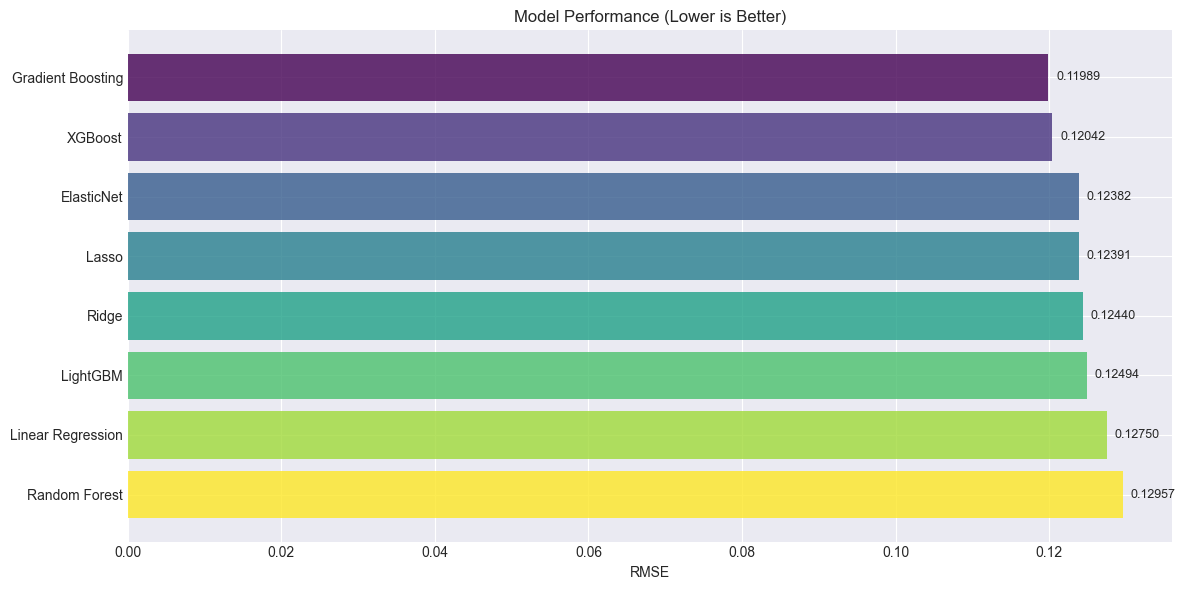

In [21]:
# ===================================================================
# 기본 모델 학습 및 성능 비교
# ===================================================================
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.kernel_ridge import KernelRidge
import xgboost as xgb
import lightgbm as lgb
import time

model_results = {}

# 1. Linear Regression
print("\n[1] Linear Regression")
lr = LinearRegression()
lr.fit(X_tr, y_tr)
pred_lr = lr.predict(X_val)
rmse_lr = rmse(y_val, pred_lr)
model_results['Linear Regression'] = rmse_lr
print(f"   Validation RMSE: {rmse_lr:.5f}")

# 2. Ridge Regression
print("\n[2] Ridge Regression")
ridge = Ridge(alpha=10.0, random_state=42)
ridge.fit(X_tr, y_tr)
pred_ridge = ridge.predict(X_val)
rmse_ridge_val = rmse(y_val, pred_ridge)
model_results['Ridge'] = rmse_ridge_val
print(f"   Validation RMSE: {rmse_ridge_val:.5f}")

# 3. Lasso Regression
print("\n[3] Lasso Regression")
lasso = Lasso(alpha=0.0005, random_state=42, max_iter=10000)
lasso.fit(X_tr, y_tr)
pred_lasso = lasso.predict(X_val)
rmse_lasso_val = rmse(y_val, pred_lasso)
model_results['Lasso'] = rmse_lasso_val
print(f"   Validation RMSE: {rmse_lasso_val:.5f}")

# 4. ElasticNet
print("\n[4] ElasticNet")
elastic = ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=42, max_iter=10000)
elastic.fit(X_tr, y_tr)
pred_elastic = elastic.predict(X_val)
rmse_elastic_val = rmse(y_val, pred_elastic)
model_results['ElasticNet'] = rmse_elastic_val
print(f"   Validation RMSE: {rmse_elastic_val:.5f}")

# 5. Random Forest
print("\n[5] Random Forest")
rf = RandomForestRegressor(n_estimators=300, max_depth=15, min_samples_split=5,
                           min_samples_leaf=2, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)
pred_rf = rf.predict(X_val)
rmse_rf_val = rmse(y_val, pred_rf)
model_results['Random Forest'] = rmse_rf_val
print(f"   Validation RMSE: {rmse_rf_val:.5f}")

# 6. Gradient Boosting
print("\n[6] Gradient Boosting")
gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                                min_samples_split=5, random_state=42)
gb.fit(X_tr, y_tr)
pred_gb = gb.predict(X_val)
rmse_gb_val = rmse(y_val, pred_gb)
model_results['Gradient Boosting'] = rmse_gb_val
print(f"   Validation RMSE: {rmse_gb_val:.5f}")

# 7. XGBoost
print("\n[7] XGBoost")
xgb_model = xgb.XGBRegressor(
    n_estimators=1000, learning_rate=0.05, max_depth=4,
    min_child_weight=3, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.0005, reg_lambda=1.0, random_state=42,
    n_jobs=-1, verbosity=0
)
xgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
pred_xgb = xgb_model.predict(X_val)
rmse_xgb_val = rmse(y_val, pred_xgb)
model_results['XGBoost'] = rmse_xgb_val
print(f"   Validation RMSE: {rmse_xgb_val:.5f}")

# 8. LightGBM
print("\n[8] LightGBM")
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000, learning_rate=0.05, max_depth=4,
    num_leaves=31, min_child_samples=20, subsample=0.8,
    colsample_bytree=0.8, reg_alpha=0.0005, reg_lambda=1.0,
    random_state=42, n_jobs=-1, verbosity=-1
)
lgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
pred_lgb = lgb_model.predict(X_val)
rmse_lgb_val = rmse(y_val, pred_lgb)
model_results['LightGBM'] = rmse_lgb_val
print(f"   Validation RMSE: {rmse_lgb_val:.5f}")

# 결과 정리
print("\n" + "=" * 60)
print("모델 성능 비교 (Validation RMSE)")
print("=" * 60)
results_df = pd.DataFrame({
    'Model': list(model_results.keys()),
    'RMSE': list(model_results.values())
}).sort_values('RMSE')
print(results_df.to_string(index=False))

# 시각화
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(results_df)))
bars = ax.barh(results_df['Model'], results_df['RMSE'], color=colors, alpha=0.8)
ax.set_xlabel('RMSE')
ax.set_title('Model Performance (Lower is Better)')
ax.invert_yaxis()
for i, (bar, v) in enumerate(zip(bars, results_df['RMSE'])):
    ax.text(v + 0.001, i, f'{v:.5f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 5.2 하이퍼파라미터 최적화 (Optuna)

[00:12:49] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:767: 
Parameters: { "device" } are not used.

XGBoost GPU 사용 가능
LightGBM GPU 사용 가능

[1/6] Ridge 최적화...


  0%|          | 0/100 [00:00<?, ?it/s]

   Best: 0.12047 | alpha=19.5226

[2/6] Lasso 최적화...


  0%|          | 0/100 [00:00<?, ?it/s]

   Best: 0.11769 | alpha=0.000184

[3/6] ElasticNet 최적화...


...

   Best: 0.12046

[5/6] XGBoost 최적화...


  0%|          | 0/100 [00:00<?, ?it/s]

   Best: 0.12138

[6/6] LightGBM 최적화...


  0%|          | 0/100 [00:00<?, ?it/s]

   Best: 0.12139

Optuna 최적화 결과 요약
   Lasso               : 0.11769
   ElasticNet          : 0.11770
   GradientBoosting    : 0.12046
   Ridge               : 0.12047
   XGBoost             : 0.12138
   LightGBM            : 0.12139


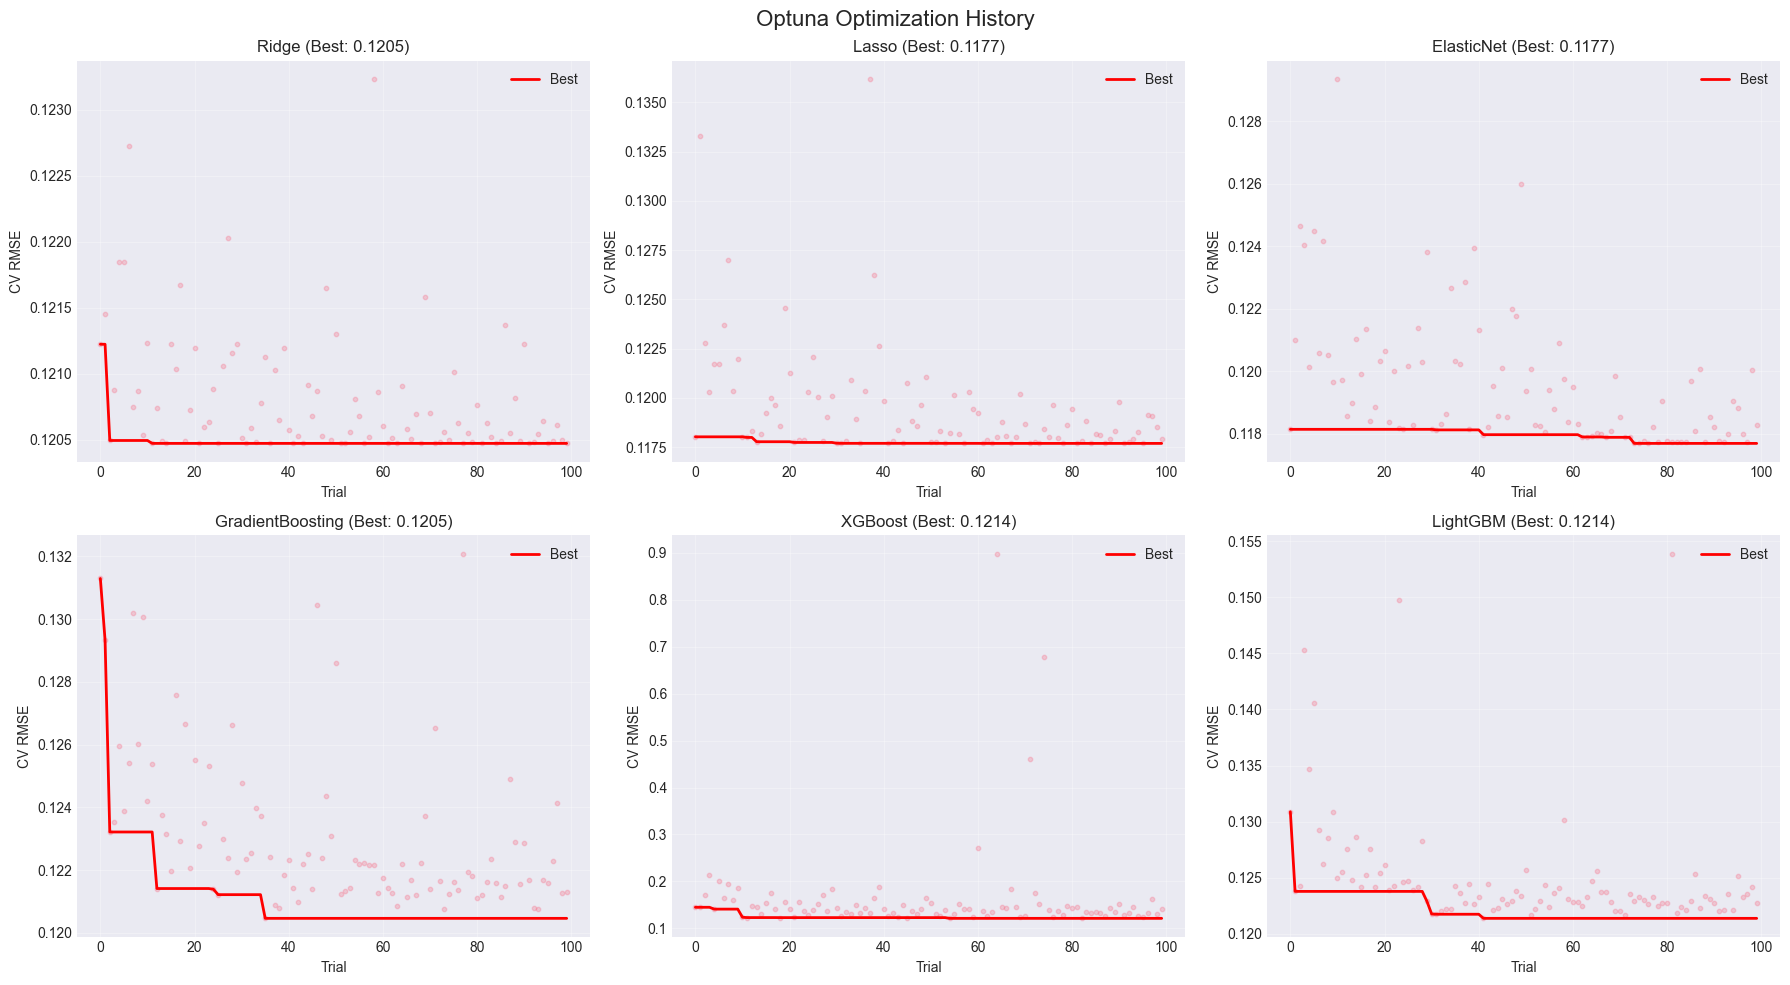

In [22]:
# ===================================================================
# Optuna 하이퍼파라미터 최적화 (6개 모델)
# ===================================================================
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# GPU 사용 가능 여부 확인
try:
    test_xgb = xgb.XGBRegressor(device='cuda:0', tree_method='hist', n_estimators=10)
    test_xgb.fit(X_tr[:100], y_tr[:100])
    USE_GPU_XGB = True
    print("XGBoost GPU 사용 가능")
except Exception:
    USE_GPU_XGB = False
    print("XGBoost CPU 모드")

try:
    test_lgb = lgb.LGBMRegressor(device='gpu', n_estimators=10, verbosity=-1)
    test_lgb.fit(X_tr[:100], y_tr[:100])
    USE_GPU_LGB = True
    print("LightGBM GPU 사용 가능")
except Exception:
    USE_GPU_LGB = False
    print("LightGBM CPU 모드")

N_TRIALS = 100  # 각 모델당 trials 수

# ---------- 1. Ridge ----------
print("\n[1/6] Ridge 최적화...")
def objective_ridge(trial):
    alpha = trial.suggest_float('alpha', 0.1, 100.0, log=True)
    model = Ridge(alpha=alpha, random_state=42)
    scores = cross_val_score(model, X_train_scaled, y_train_clean,
                             scoring='neg_root_mean_squared_error', cv=kf)
    return -scores.mean()

study_ridge = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study_ridge.optimize(objective_ridge, n_trials=N_TRIALS, show_progress_bar=True)
print(f"   Best: {study_ridge.best_value:.5f} | alpha={study_ridge.best_params['alpha']:.4f}")

# ---------- 2. Lasso ----------
print("\n[2/6] Lasso 최적화...")
def objective_lasso(trial):
    alpha = trial.suggest_float('alpha', 1e-5, 0.01, log=True)
    model = Lasso(alpha=alpha, random_state=42, max_iter=10000)
    scores = cross_val_score(model, X_train_scaled, y_train_clean,
                             scoring='neg_root_mean_squared_error', cv=kf)
    return -scores.mean()

study_lasso = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study_lasso.optimize(objective_lasso, n_trials=N_TRIALS, show_progress_bar=True)
print(f"   Best: {study_lasso.best_value:.5f} | alpha={study_lasso.best_params['alpha']:.6f}")

# ---------- 3. ElasticNet ----------
print("\n[3/6] ElasticNet 최적화...")
def objective_elastic(trial):
    alpha = trial.suggest_float('alpha', 1e-5, 0.01, log=True)
    l1_ratio = trial.suggest_float('l1_ratio', 0.01, 0.99)
    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42, max_iter=10000)
    scores = cross_val_score(model, X_train_scaled, y_train_clean,
                             scoring='neg_root_mean_squared_error', cv=kf)
    return -scores.mean()

study_elastic = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study_elastic.optimize(objective_elastic, n_trials=N_TRIALS, show_progress_bar=True)
print(f"   Best: {study_elastic.best_value:.5f}")

# ---------- 4. Gradient Boosting ----------
print("\n[4/6] Gradient Boosting 최적화...")
def objective_gb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 6),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
    }
    model = GradientBoostingRegressor(**params, random_state=42)
    scores = cross_val_score(model, X_train_scaled, y_train_clean,
                             scoring='neg_root_mean_squared_error', cv=kf)
    return -scores.mean()

study_gb = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study_gb.optimize(objective_gb, n_trials=N_TRIALS, show_progress_bar=True)
print(f"   Best: {study_gb.best_value:.5f}")

# ---------- 5. XGBoost ----------
print("\n[5/6] XGBoost 최적화...")
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 3000, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-5, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-5, 10.0, log=True),
    }
    extra = {'random_state': 42, 'verbosity': 0}
    if USE_GPU_XGB:
        extra.update({'device': 'cuda:0', 'tree_method': 'hist', 'n_jobs': 1})
    else:
        extra['n_jobs'] = -1
    model = xgb.XGBRegressor(**params, **extra)
    scores = cross_val_score(model, X_train_scaled, y_train_clean,
                             scoring='neg_root_mean_squared_error', cv=kf)
    return -scores.mean()

study_xgb = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS, show_progress_bar=True)
print(f"   Best: {study_xgb.best_value:.5f}")

# ---------- 6. LightGBM ----------
print("\n[6/6] LightGBM 최적화...")
def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 3000, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-5, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-5, 10.0, log=True),
    }
    extra = {'random_state': 42, 'verbosity': -1}
    if USE_GPU_LGB:
        extra.update({'device': 'gpu', 'n_jobs': 1})
    else:
        extra['n_jobs'] = -1
    model = lgb.LGBMRegressor(**params, **extra)
    scores = cross_val_score(model, X_train_scaled, y_train_clean,
                             scoring='neg_root_mean_squared_error', cv=kf)
    return -scores.mean()

study_lgb = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study_lgb.optimize(objective_lgb, n_trials=N_TRIALS, show_progress_bar=True)
print(f"   Best: {study_lgb.best_value:.5f}")

# 최적화 결과 요약
print("\n" + "=" * 60)
print("Optuna 최적화 결과 요약")
print("=" * 60)
opt_results = {
    'Ridge': study_ridge.best_value,
    'Lasso': study_lasso.best_value,
    'ElasticNet': study_elastic.best_value,
    'GradientBoosting': study_gb.best_value,
    'XGBoost': study_xgb.best_value,
    'LightGBM': study_lgb.best_value
}
for name, score in sorted(opt_results.items(), key=lambda x: x[1]):
    print(f"   {name:20s}: {score:.5f}")

# Optuna 시각화
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Optuna Optimization History', fontsize=16)

studies = [
    ('Ridge', study_ridge), ('Lasso', study_lasso), ('ElasticNet', study_elastic),
    ('GradientBoosting', study_gb), ('XGBoost', study_xgb), ('LightGBM', study_lgb)
]

for ax, (name, study) in zip(axes.flatten(), studies):
    trials = study.trials
    vals = [t.value for t in trials if t.value is not None]
    best_vals = [min(vals[:i+1]) for i in range(len(vals))]
    ax.scatter(range(len(vals)), vals, alpha=0.3, s=10)
    ax.plot(range(len(best_vals)), best_vals, 'r-', linewidth=2, label='Best')
    ax.set_title(f'{name} (Best: {study.best_value:.4f})')
    ax.set_xlabel('Trial')
    ax.set_ylabel('CV RMSE')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5.3 앙상블 (Voting + Stacking)

In [23]:
# ===================================================================
# 앙상블 모델 구축
# ===================================================================
from sklearn.ensemble import StackingRegressor, VotingRegressor

# Optuna 최적 파라미터로 모델 생성
xgb_extra = {'random_state': 42, 'verbosity': 0}
if USE_GPU_XGB:
    xgb_extra.update({'device': 'cuda:0', 'tree_method': 'hist', 'n_jobs': 1})
else:
    xgb_extra['n_jobs'] = -1

lgb_extra = {'random_state': 42, 'verbosity': -1}
if USE_GPU_LGB:
    lgb_extra.update({'device': 'gpu', 'n_jobs': 1})
else:
    lgb_extra['n_jobs'] = -1

ridge_opt = Ridge(**study_ridge.best_params, random_state=42)
lasso_opt = Lasso(**study_lasso.best_params, random_state=42, max_iter=10000)
elastic_opt = ElasticNet(**study_elastic.best_params, random_state=42, max_iter=10000)
gb_opt = GradientBoostingRegressor(**study_gb.best_params, random_state=42)
xgb_opt = xgb.XGBRegressor(**study_xgb.best_params, **xgb_extra)
lgb_opt = lgb.LGBMRegressor(**study_lgb.best_params, **lgb_extra)

# ===== 방법 1: 가중 평균 앙상블 (CV로 가중치 결정) =====
print("=" * 60)
print("[방법 1] 가중 평균 앙상블")
print("=" * 60)

models_for_blend = {
    'Ridge': Ridge(**study_ridge.best_params, random_state=42),
    'Lasso': Lasso(**study_lasso.best_params, random_state=42, max_iter=10000),
    'ElasticNet': ElasticNet(**study_elastic.best_params, random_state=42, max_iter=10000),
    'GB': GradientBoostingRegressor(**study_gb.best_params, random_state=42),
    'XGBoost': xgb.XGBRegressor(**study_xgb.best_params, **xgb_extra),
    'LightGBM': lgb.LGBMRegressor(**study_lgb.best_params, **lgb_extra),
}

# CV로 각 모델 점수 계산
cv_scores = {}
for name, model in models_for_blend.items():
    mean_score, std_score = cv_rmse(model, X_train_scaled, y_train_clean, cv=5)
    cv_scores[name] = mean_score
    print(f"   {name:15s}: {mean_score:.5f} (+/- {std_score:.5f})")

# 성능 역수 기반 가중치
inv_scores = {k: 1/v for k, v in cv_scores.items()}
total = sum(inv_scores.values())
weights = {k: v/total for k, v in inv_scores.items()}

print(f"\n   가중치:")
for name, w in weights.items():
    print(f"   {name:15s}: {w:.3f}")

# 가중 평균 CV 평가
kf = KFold(n_splits=5, shuffle=True, random_state=42)
blend_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_scaled)):
    X_tr_fold = X_train_scaled[train_idx]
    X_val_fold = X_train_scaled[val_idx]
    y_tr_fold = y_train_clean.iloc[train_idx]
    y_val_fold = y_train_clean.iloc[val_idx]
    
    preds = {}
    for name, model in models_for_blend.items():
        m = type(model)(**model.get_params())
        m.fit(X_tr_fold, y_tr_fold)
        preds[name] = m.predict(X_val_fold)
    
    blend_pred = sum(weights[name] * preds[name] for name in preds)
    fold_rmse = rmse(y_val_fold, blend_pred)
    blend_scores.append(fold_rmse)

blend_mean = np.mean(blend_scores)
blend_std = np.std(blend_scores)
print(f"\n   가중 평균 앙상블 CV RMSE: {blend_mean:.5f} (+/- {blend_std:.5f})")

# ===== 방법 2: Stacking 앙상블 =====
print("\n" + "=" * 60)
print("[방법 2] Stacking 앙상블")
print("=" * 60)

base_models = [
    ('ridge', Ridge(**study_ridge.best_params, random_state=42)),
    ('lasso', Lasso(**study_lasso.best_params, random_state=42, max_iter=10000)),
    ('elastic', ElasticNet(**study_elastic.best_params, random_state=42, max_iter=10000)),
    ('gb', GradientBoostingRegressor(**study_gb.best_params, random_state=42)),
    ('xgb', xgb.XGBRegressor(**study_xgb.best_params, **xgb_extra)),
    ('lgb', lgb.LGBMRegressor(**study_lgb.best_params, **lgb_extra)),
]

# Meta 모델: Lasso (L1 규제로 불필요한 base 모델 자동 제거)
meta_model = Lasso(alpha=0.0005, random_state=42, max_iter=10000)

stacking = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    n_jobs=1  # GPU 모델 충돌 방지
)

# Stacking CV 평가
stack_scores = []
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_scaled)):
    X_tr_fold = X_train_scaled[train_idx]
    X_val_fold = X_train_scaled[val_idx]
    y_tr_fold = y_train_clean.iloc[train_idx]
    y_val_fold = y_train_clean.iloc[val_idx]
    
    stack_model = StackingRegressor(
        estimators=[
            ('ridge', Ridge(**study_ridge.best_params, random_state=42)),
            ('lasso', Lasso(**study_lasso.best_params, random_state=42, max_iter=10000)),
            ('elastic', ElasticNet(**study_elastic.best_params, random_state=42, max_iter=10000)),
            ('gb', GradientBoostingRegressor(**study_gb.best_params, random_state=42)),
            ('xgb', xgb.XGBRegressor(**study_xgb.best_params, **xgb_extra)),
            ('lgb', lgb.LGBMRegressor(**study_lgb.best_params, **lgb_extra)),
        ],
        final_estimator=Lasso(alpha=0.0005, random_state=42, max_iter=10000),
        cv=5, n_jobs=1
    )
    stack_model.fit(X_tr_fold, y_tr_fold)
    pred_stack = stack_model.predict(X_val_fold)
    fold_rmse = rmse(y_val_fold, pred_stack)
    stack_scores.append(fold_rmse)
    print(f"   Fold {fold+1}: {fold_rmse:.5f}")

stack_mean = np.mean(stack_scores)
stack_std = np.std(stack_scores)
print(f"\n   Stacking CV RMSE: {stack_mean:.5f} (+/- {stack_std:.5f})")

# ===== 방법 3: Blend + Stack 혼합 =====
print("\n" + "=" * 60)
print("[방법 3] Blend + Stack 혼합")
print("=" * 60)

hybrid_scores = []
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_scaled)):
    X_tr_fold = X_train_scaled[train_idx]
    X_val_fold = X_train_scaled[val_idx]
    y_tr_fold = y_train_clean.iloc[train_idx]
    y_val_fold = y_train_clean.iloc[val_idx]
    
    # Blend 예측
    preds = {}
    for name, model in models_for_blend.items():
        m = type(model)(**model.get_params())
        m.fit(X_tr_fold, y_tr_fold)
        preds[name] = m.predict(X_val_fold)
    blend_pred = sum(weights[name] * preds[name] for name in preds)
    
    # Stack 예측
    stack_model = StackingRegressor(
        estimators=[
            ('ridge', Ridge(**study_ridge.best_params, random_state=42)),
            ('lasso', Lasso(**study_lasso.best_params, random_state=42, max_iter=10000)),
            ('elastic', ElasticNet(**study_elastic.best_params, random_state=42, max_iter=10000)),
            ('gb', GradientBoostingRegressor(**study_gb.best_params, random_state=42)),
            ('xgb', xgb.XGBRegressor(**study_xgb.best_params, **xgb_extra)),
            ('lgb', lgb.LGBMRegressor(**study_lgb.best_params, **lgb_extra)),
        ],
        final_estimator=Lasso(alpha=0.0005, random_state=42, max_iter=10000),
        cv=5, n_jobs=1
    )
    stack_model.fit(X_tr_fold, y_tr_fold)
    stack_pred = stack_model.predict(X_val_fold)
    
    # 혼합 (70% Stack + 30% Blend)
    hybrid_pred = 0.7 * stack_pred + 0.3 * blend_pred
    fold_rmse = rmse(y_val_fold, hybrid_pred)
    hybrid_scores.append(fold_rmse)

hybrid_mean = np.mean(hybrid_scores)
hybrid_std = np.std(hybrid_scores)
print(f"   Hybrid CV RMSE: {hybrid_mean:.5f} (+/- {hybrid_std:.5f})")

# 최종 비교
print("\n" + "=" * 60)
print("최종 앙상블 성능 비교")
print("=" * 60)

all_methods = {
    '가중 평균 앙상블': (blend_mean, blend_std),
    'Stacking': (stack_mean, stack_std),
    'Hybrid (Stack+Blend)': (hybrid_mean, hybrid_std),
}
# 개별 모델 최고도 포함
best_single = min(cv_scores.items(), key=lambda x: x[1])
all_methods[f'Best Single ({best_single[0]})'] = (best_single[1], 0.0)

for name, (mean_v, std_v) in sorted(all_methods.items(), key=lambda x: x[1][0]):
    print(f"   {name:30s}: {mean_v:.5f} (+/- {std_v:.5f})")

best_method_name = min(all_methods, key=lambda x: all_methods[x][0])
best_cv = all_methods[best_method_name][0]
print(f"\n최고: {best_method_name} (RMSE: {best_cv:.5f})")

[방법 1] 가중 평균 앙상블
   Ridge          : 0.12047 (+/- 0.01021)
   Lasso          : 0.11769 (+/- 0.01044)
   ElasticNet     : 0.11770 (+/- 0.01044)
   GB             : 0.12046 (+/- 0.00815)
   XGBoost        : 0.12138 (+/- 0.01057)
   LightGBM       : 0.12137 (+/- 0.01120)

   가중치:
   Ridge          : 0.166
   Lasso          : 0.170
   ElasticNet     : 0.170
   GB             : 0.166
   XGBoost        : 0.165
   LightGBM       : 0.165

   가중 평균 앙상블 CV RMSE: 0.11387 (+/- 0.00956)

[방법 2] Stacking 앙상블
   Fold 1: 0.11501
   Fold 2: 0.10939
   Fold 3: 0.11926
   Fold 4: 0.09924
   Fold 5: 0.12637

   Stacking CV RMSE: 0.11385 (+/- 0.00917)

[방법 3] Blend + Stack 혼합
   Hybrid CV RMSE: 0.11380 (+/- 0.00930)

최종 앙상블 성능 비교
   Hybrid (Stack+Blend)          : 0.11380 (+/- 0.00930)
   Stacking                      : 0.11385 (+/- 0.00917)
   가중 평균 앙상블                     : 0.11387 (+/- 0.00956)
   Best Single (Lasso)           : 0.11769 (+/- 0.00000)

최고: Hybrid (Stack+Blend) (RMSE: 0.11380)


# 6. 최종 제출 파일 생성

In [24]:
# ===================================================================
# 최종 모델 학습 + 제출 파일 생성
# ===================================================================
print("=" * 60)
print("최종 모델 학습 (전체 Train 데이터)")
print("=" * 60)

# 전체 데이터로 최종 모델 재학습
ridge_final = Ridge(**study_ridge.best_params, random_state=42)
ridge_final.fit(X_train_scaled, y_train_clean)

lasso_final = Lasso(**study_lasso.best_params, random_state=42, max_iter=10000)
lasso_final.fit(X_train_scaled, y_train_clean)

elastic_final = ElasticNet(**study_elastic.best_params, random_state=42, max_iter=10000)
elastic_final.fit(X_train_scaled, y_train_clean)

gb_final = GradientBoostingRegressor(**study_gb.best_params, random_state=42)
gb_final.fit(X_train_scaled, y_train_clean)

xgb_final = xgb.XGBRegressor(**study_xgb.best_params, **xgb_extra)
xgb_final.fit(X_train_scaled, y_train_clean, verbose=False)

lgb_final = lgb.LGBMRegressor(**study_lgb.best_params, **lgb_extra)
lgb_final.fit(X_train_scaled, y_train_clean)

print("모델 학습 완료!")

# 예측
pred_ridge_sub = ridge_final.predict(X_submission_scaled)
pred_lasso_sub = lasso_final.predict(X_submission_scaled)
pred_elastic_sub = elastic_final.predict(X_submission_scaled)
pred_gb_sub = gb_final.predict(X_submission_scaled)
pred_xgb_sub = xgb_final.predict(X_submission_scaled)
pred_lgb_sub = lgb_final.predict(X_submission_scaled)

# === 제출 1: 가중 평균 앙상블 ===
blend_pred_sub = (
    weights['Ridge'] * pred_ridge_sub +
    weights['Lasso'] * pred_lasso_sub +
    weights['ElasticNet'] * pred_elastic_sub +
    weights['GB'] * pred_gb_sub +
    weights['XGBoost'] * pred_xgb_sub +
    weights['LightGBM'] * pred_lgb_sub
)

submission_blend = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': np.expm1(blend_pred_sub)
})
submission_blend.to_csv('submission_blend_final.csv', index=False)
print(f"\nsubmission_blend_final.csv 생성 (CV RMSE: {blend_mean:.5f})")

# === 제출 2: Stacking 앙상블 ===
stacking_final = StackingRegressor(
    estimators=[
        ('ridge', Ridge(**study_ridge.best_params, random_state=42)),
        ('lasso', Lasso(**study_lasso.best_params, random_state=42, max_iter=10000)),
        ('elastic', ElasticNet(**study_elastic.best_params, random_state=42, max_iter=10000)),
        ('gb', GradientBoostingRegressor(**study_gb.best_params, random_state=42)),
        ('xgb', xgb.XGBRegressor(**study_xgb.best_params, **xgb_extra)),
        ('lgb', lgb.LGBMRegressor(**study_lgb.best_params, **lgb_extra)),
    ],
    final_estimator=Lasso(alpha=0.0005, random_state=42, max_iter=10000),
    cv=5, n_jobs=1
)
stacking_final.fit(X_train_scaled, y_train_clean)
stack_pred_sub = stacking_final.predict(X_submission_scaled)

submission_stack = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': np.expm1(stack_pred_sub)
})
submission_stack.to_csv('submission_stacking_final.csv', index=False)
print(f"submission_stacking_final.csv 생성 (CV RMSE: {stack_mean:.5f})")

# === 제출 3: Hybrid (Stack 70% + Blend 30%) ===
hybrid_pred_sub = 0.7 * stack_pred_sub + 0.3 * blend_pred_sub

submission_hybrid = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': np.expm1(hybrid_pred_sub)
})
submission_hybrid.to_csv('submission_hybrid_final.csv', index=False)
print(f"submission_hybrid_final.csv 생성 (CV RMSE: {hybrid_mean:.5f})")

# 최종 요약
print("\n" + "=" * 60)
print("최종 요약")
print("=" * 60)
print(f"Blend 예상 LB:  {blend_mean:.4f} (log RMSE)")
print(f"Stack 예상 LB:  {stack_mean:.4f} (log RMSE)")
print(f"Hybrid 예상 LB: {hybrid_mean:.4f} (log RMSE)")
print(f"\n가격 범위 (Hybrid):")
print(f"  최소: ${submission_hybrid['SalePrice'].min():,.0f}")
print(f"  최대: ${submission_hybrid['SalePrice'].max():,.0f}")
print(f"  평균: ${submission_hybrid['SalePrice'].mean():,.0f}")
print(f"\n파일:")
print(f"  1. submission_blend_final.csv")
print(f"  2. submission_stacking_final.csv")
print(f"  3. submission_hybrid_final.csv")
print("\n가장 낮은 CV RMSE의 파일을 Kaggle에 제출하세요!")

최종 모델 학습 (전체 Train 데이터)
모델 학습 완료!

submission_blend_final.csv 생성 (CV RMSE: 0.11387)
submission_stacking_final.csv 생성 (CV RMSE: 0.11385)
submission_hybrid_final.csv 생성 (CV RMSE: 0.11380)

최종 요약
Blend 예상 LB:  0.1139 (log RMSE)
Stack 예상 LB:  0.1139 (log RMSE)
Hybrid 예상 LB: 0.1138 (log RMSE)

가격 범위 (Hybrid):
  최소: $54,986
  최대: $545,411
  평균: $179,612

파일:
  1. submission_blend_final.csv
  2. submission_stacking_final.csv
  3. submission_hybrid_final.csv

가장 낮은 CV RMSE의 파일을 Kaggle에 제출하세요!
